# Gradient Boosting (GB) on the MALL Extended 5-min Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the Gradient Boosting (GB) model on the MALL Extended 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The Gradient Boosting model builds on regression trees by combining a sequence of weak learners, where each new tree is fitted to improve upon the errors made by the previous ones. In contrast to Random Forest and Bagging, which average many independently grown trees, Gradient Boosting constructs trees sequentially and is therefore better suited to capturing more complex nonlinear relationships across a broader macro-financial, cross-market, and euro-area spread information set.

The final MALL extended feature set used in this notebook is:

- `RVD`, `RVW`, `RVM`
- `VSTOXX`
- `CISS`
- `logEPU_1m_lag`
- `EURUSD_ret`
- `BRENT_ret`
- `NIKKEI_ret`, `NIKKEI_sq`
- `SP500_ret_lag`, `SP500_sq_lag`
- `M1W`, `M1M`
- `EURIBOR_OIS_CS`, `TERM_CS`

The baseline forecasting relation is written as:

$$
RV_{t+1} = f(Z_t) + \varepsilon_{t+1},
$$

where $Z_t$ denotes the final MALL extended predictor vector used in this notebook. In the Gradient Boosting model, the prediction function is updated iteratively as:

$$
\hat{f}_b(Z_t)
=
\hat{f}_{b-1}(Z_t)
+
\eta \sum_{j=1}^{J_b} q_{jb}\mathbf{1}\{Z_t \in R_{jb}\},
\qquad b = 1, \dots, B,
$$

where $\eta$ is the learning rate, $R_{jb}$ denotes the $j$-th terminal node of tree $b$, and $q_{jb}$ is the corresponding node-specific update. In line with the paper, GB is treated as a tuned tree-based model, so the hyperparameters are selected by validation-set MSE and re-tuned inside each rolling window over the test period.

## 1. Loading Data
Loading in data from the `MALL_extended_5min.csv` file.

In [4]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# Load MALL extended dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_extended_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5489, 39)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,EURIBOR_3M,EURIBOR_3M_diff,EURO_10Y_SWAP,EURO_10Y_SWAP_diff,EURO_3M_OVERNIGHT_INDEX,EURO_3M_OVERNIGHT_INDEX_diff,EURIBOR_OIS_CS,TERM_CS,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,3.222,-0.012,4.160,-0.005,3.115,0.035,0.107,0.938,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,3.214,-0.008,4.162,0.002,3.100,-0.015,0.114,0.948,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,3.206,-0.008,4.160,-0.002,3.090,-0.010,0.116,0.954,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,3.196,-0.010,4.130,-0.030,3.095,0.005,0.101,0.934,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,3.193,-0.003,4.225,0.095,3.090,-0.005,0.103,1.032,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). The test set is reserved exclusively for out-of-sample evaluation, while the validation block is used to select the Gradient Boosting hyperparameters both in the initial split and inside each rolling estimation window.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 3. Gradient Boosting
### 3.1 Model Specification


The Gradient Boosting model replaces the linear HAR forecasting equation with an additive ensemble of shallow regression trees. Because the MALL extended feature set is much richer than the MHAR specification, GB is especially well suited here to capturing nonlinear interactions and threshold effects across volatility, macro-financial, global spillover, and euro-area spread variables.

### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the GB model.


In [13]:
# Define target and final MALL extended feature set
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M",
    "EURIBOR_OIS_CS", "TERM_CS"
]

y = MALL["RV_target"].values
X_MALL = MALL[feature_cols].values

# Split into train, validation and test sets
X_train = X_MALL[:n_train]
X_val = X_MALL[n_train:n_train + n_val]
X_test = X_MALL[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Standardize predictors using training-sample moments for consistency across notebooks
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

X_scaled = (X_MALL - X_mean) / X_std
X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

print("Feature set:")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Mean of first 5 columns: {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"  Std of first 5 columns:  {X_train_scaled.std(axis=0)[:5].round(6)}")

Feature set:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M
  - EURIBOR_OIS_CS
  - TERM_CS

Full dataset:   X=(5489, 16), y=(5489,)
Training set:   X=(3842, 16), y=(3842,)
Validation set: X=(548, 16), y=(548,)
Test set:       X=(1099, 16), y=(1099,)

Standardization check on training sample:
  Mean of first 5 columns: [ 0. -0. -0. -0.  0.]
  Std of first 5 columns:  [1. 1. 1. 1. 1.]


## 5. Gradient Boosting Model Specification and Hyperparameter Tuning

Appendix A.4 of the paper tunes three GB hyperparameters in the validation set: tree depth in `{1, 2}`, number of trees in `{50, 100, ..., 500}`, and learning rate in `{0.01, 0.1}`. The same grid is used below both for the initial validation exercise and for the rolling re-tuning stage over the test period for the MALL extended specification.

In [16]:
# Gradient Boosting hyperparameter grid following the paper
depth_grid = [1, 2]
n_estimators_grid = list(range(50, 501, 50))
learning_rate_grid = [0.01, 0.1]

grid_records = []
best_mse = np.inf
best_params_initial = None

for depth in depth_grid:
    for n_estimators in n_estimators_grid:
        for learning_rate in learning_rate_grid:
            model = GradientBoostingRegressor(
                max_depth=depth,
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                random_state=42
            )
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_val_scaled)
            mse = np.mean((y_val - y_pred) ** 2)

            grid_records.append({
                "depth": depth,
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "val_mse": mse
            })

            if mse < best_mse:
                best_mse = mse
                best_params_initial = {
                    "depth": depth,
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate
                }

print(f"Depth grid: {depth_grid}")
print(f"Tree grid:  {n_estimators_grid}")
print(f"LR grid:    {learning_rate_grid}")
print(f"Best initial validation parameters: {best_params_initial}")
print(f"Best initial validation MSE: {best_mse:.6e}")

grid_results = pd.DataFrame(grid_records).sort_values("val_mse")
display(grid_results.head(10))


Depth grid: [1, 2]
Tree grid:  [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
LR grid:    [0.01, 0.1]
Best initial validation parameters: {'depth': 1, 'n_estimators': 400, 'learning_rate': 0.1}
Best initial validation MSE: 9.793733e-09


,depth,n_estimators,learning_rate,val_mse
15,1,400,0.1,9.793733e-09
17,1,450,0.1,9.798728e-09
13,1,350,0.1,9.800605e-09
19,1,500,0.1,9.805068e-09
11,1,300,0.1,9.859070e-09
9,1,250,0.1,9.866925e-09
7,1,200,0.1,9.903871e-09
5,1,150,0.1,9.950399e-09
3,1,100,0.1,9.981814e-09
21,2,50,0.1,1.014291e-08


## 6. Rolling Window Tuning, Estimation, and Forecasting

Following the paper, GB is treated as a tuned model. At each forecast origin, the hyperparameters are re-selected using the validation block within the current rolling window, after which the best-performing specification is used to generate the one-day-ahead forecast.


In [19]:
window_size = n_train + n_val

depth_grid = [1, 2]
n_estimators_grid = list(range(50, 501, 50))
learning_rate_grid = [0.01, 0.1]

forecasts_GB = []
dates_test = []
best_params_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    X_win_train = X_window[:-n_val]
    X_win_val = X_window[-n_val:]
    y_win_train = y_window[:-n_val]
    y_win_val = y_window[-n_val:]

    best_mse_window = np.inf
    best_params = None
    best_model = None

    for depth in depth_grid:
        for n_estimators in n_estimators_grid:
            for learning_rate in learning_rate_grid:
                model = GradientBoostingRegressor(
                    max_depth=depth,
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    random_state=42
                )
                model.fit(X_win_train, y_win_train)
                y_pred = model.predict(X_win_val)
                mse = np.mean((y_win_val - y_pred) ** 2)

                if mse < best_mse_window:
                    best_mse_window = mse
                    best_params = {
                        "depth": depth,
                        "n_estimators": n_estimators,
                        "learning_rate": learning_rate
                    }
                    best_model = model

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = best_model.predict(X_forecast)[0]

    # Paper-consistent floor for negative volatility forecasts
    min_rv_roll = y_window.min()
    forecast = max(forecast, min_rv_roll)

    forecasts_GB.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    best_params_path.append(best_params)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Best params: {best_params} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print()
print(f"Total estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_GB)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
display(pd.DataFrame(best_params_path).value_counts().rename("Count").reset_index())


  Day  100/1099 | Date: 2016-09-08 | Best params: {'depth': 1, 'n_estimators': 300, 'learning_rate': 0.1} | Elapsed: 155.5 min
  Day  200/1099 | Date: 2017-01-27 | Best params: {'depth': 1, 'n_estimators': 300, 'learning_rate': 0.1} | Elapsed: 327.9 min
  Day  300/1099 | Date: 2017-06-21 | Best params: {'depth': 2, 'n_estimators': 200, 'learning_rate': 0.1} | Elapsed: 586.7 min
  Day  400/1099 | Date: 2017-11-08 | Best params: {'depth': 2, 'n_estimators': 350, 'learning_rate': 0.1} | Elapsed: 1106.1 min
  Day  500/1099 | Date: 2018-04-04 | Best params: {'depth': 2, 'n_estimators': 250, 'learning_rate': 0.1} | Elapsed: 1303.8 min
  Day  600/1099 | Date: 2018-08-22 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.1} | Elapsed: 1452.6 min
  Day  700/1099 | Date: 2019-01-14 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.1} | Elapsed: 1666.3 min
  Day  800/1099 | Date: 2019-06-06 | Best params: {'depth': 2, 'n_estimators': 200, 'learning_rate': 0.1} |

,depth,n_estimators,learning_rate,Count
0,2,150,0.10,227
1,2,200,0.10,201
2,2,250,0.10,119
3,1,300,0.10,116
4,1,300,0.01,90
5,1,500,0.10,75
6,2,100,0.10,63
7,1,350,0.10,62
8,1,250,0.10,36
9,1,450,0.10,25


## 7. Save Forecasts

The forecasts and summary metrics are stored using the same file structure as the benchmark, regularized-model, and other tree-based notebooks so they can be reused in downstream model-comparison work.


In [22]:
import os

# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Tree-based Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Tree-based Models"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_GB = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_GB
}, index=dates_test)

# --- Compute errors ---
errors_GB = results_GB["RV_actual"] - results_GB["RV_forecast"]
mse_GB = np.mean(errors_GB ** 2)

# --- Save forecasts ---
results_GB.to_csv(os.path.join(forecast_path, "forecasts_GB.csv"))

# --- Save MSE summary ---
mse_summary_GB = pd.DataFrame({
    "Model": ["GB"],
    "MSE": [mse_GB],
    "RMSE": [np.sqrt(mse_GB)],
    "MAE": [errors_GB.abs().mean()],
    "Mean_Error": [errors_GB.mean()],
}).set_index("Model")

mse_summary_GB.to_csv(os.path.join(mse_path, "mse_summary_GB.csv"))

# --- Print summary ---
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_GB)}")
print(f"Gradient Boosting test-set MSE: {mse_GB:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Tree-based Models
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Tree-based Models
Rows saved: 1099
Gradient Boosting test-set MSE: 5.219472e-08


## 4. Results
### 4.1 Forecast Visualization


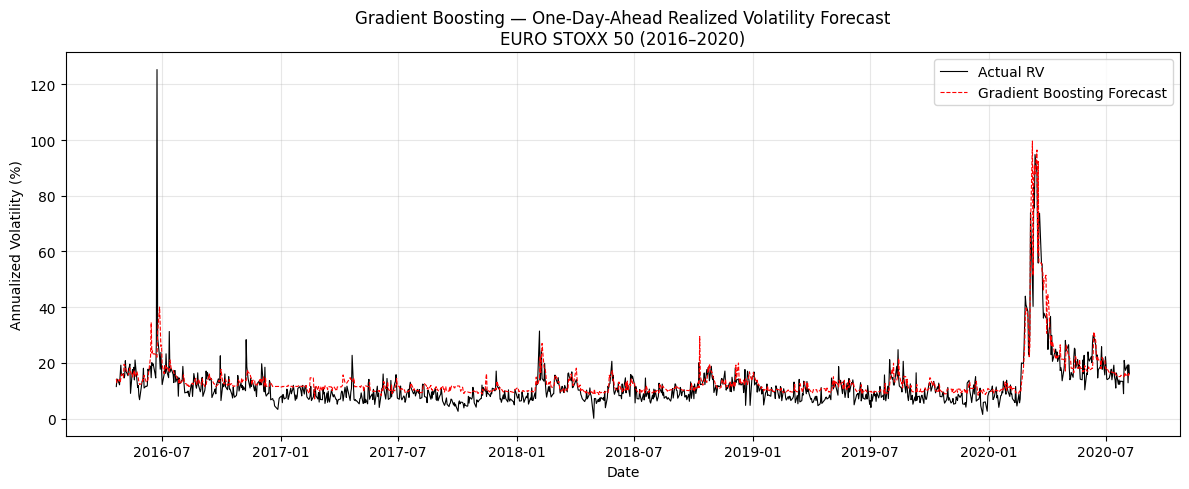


Summary of forecast errors:
Mean error:  -1.152745e-05
RMSE:        2.284616e-04
MAE:         4.574834e-05


In [25]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_GB["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_GB["RV_forecast"] * 252) * 100
}, index=results_GB.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="Gradient Boosting Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Gradient Boosting — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_GB["RV_actual"] - results_GB["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_GB):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")
